# GestaltMatcher Cohort Analysis Template

This notebook is designed as a reusable template for analyzing one or more disease/gene cohorts.

Workflow:

1. Prepare all input filenames and cohort definitions  
2. Prepare embeddings  
3. Pairwise matrix analysis  
4. Cohort-level random percentile analysis  
5. Cohort-level comparison box plots with PPV report  

The main idea is that users only edit the `CONFIG` section. All downstream analysis uses the selected cohorts and comparisons from that config.

## 0. Imports

In [1]:
import os
import json
import random
import itertools
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import pairwise_distances

## 1. Prepare all input filenames and cohort definitions

Edit this cell for each new project.

Important fields:

- `target_name`: used in output filenames.
- `run_date`: used to create the output folder.
- `gallery_embedding_file`: GMDB/reference embedding file.
- `gallery_metadata_files`: metadata files used to define the reference gallery/control set.
- `photo_metadata_file`: metadata table mapping image IDs to patient IDs, gene names, or patient labels.
- `cohorts`: one entry per cohort. Each cohort can provide its own embedding file, image-name parser, and optional filtering.
- `active_cohorts`: which cohorts should be analyzed in this run.
- `comparison_groups`: groups to include in cohort-level comparison plots. These can be single cohorts or pooled cohorts.

In [2]:
CONFIG = {
    # ---------------------------------------------------------------------
    # Project identity
    # ---------------------------------------------------------------------
    "target_name": "LINS1",
    "run_date": "2026_07_01",
    "output_root": "analysis_output",

    # ---------------------------------------------------------------------
    # Reference / GMDB gallery
    # ---------------------------------------------------------------------
    "gallery_embedding_file": "analysis_metadata/all_gmdb_encodings_v1.1.0_23052026.pkl",
    "gallery_metadata_files": [
        "analysis_metadata/gmdb_metadata/gmdb_frequent_gallery_images_v1.0.3.csv",
        "analysis_metadata/gmdb_metadata/gmdb_frequent_test_images_v1.0.3.csv",
        "analysis_metadata/gmdb_metadata/gmdb_rare_gallery_images_v1.0.3.csv",
    ],

    # Main metadata table used for image_id -> patient_id / gene / patient_name
    "photo_metadata_file": "analysis_metadata/patient_metadata_23052026.tsv",
    "photo_metadata_sep": "\t",
    "frontal_face_only": True,

    # ---------------------------------------------------------------------
    # Input cohorts
    # ---------------------------------------------------------------------
    "cohorts": {
        "LINS1": {
            # TODO: check this filename. It currently says PRMT7 although target is LINS1.
            "embedding_file": "analysis_metadata/PRMT7_embeddings_04102025_v1.1.0.pkl",
            "img_name_parser": "drop_last_token",
            "label": "LINS1",
            "exclude_image_ids": [],
        },

        "CTNND2": {
            "embedding_file": "analysis_metadata/CTNND2_gmdb_encodings_v1.1.0.pkl",
            "img_name_parser": "drop_last_token",
            "label": "CTNND2",
            "exclude_image_ids": [],
        },
    },

    # Cohorts to load and analyze in this run
    "active_cohorts": ["LINS1", "CTNND2"],

    # ---------------------------------------------------------------------
    # Within-cohort / pooled group analyses
    # ---------------------------------------------------------------------
    # For within-cohort heatmap and random percentile analysis,
    # keep each cohort as its own group.
    #
    # Do NOT use only "LINS1+CTNND2" here unless you intentionally want to pool
    # both cohorts into one combined group.
    "comparison_groups": {
        "LINS1": ["LINS1"],
        "CTNND2": ["CTNND2"],

        # Optional pooled group, only if needed:
        # "LINS1+CTNND2": ["LINS1", "CTNND2"],
    },

    # ---------------------------------------------------------------------
    # Analysis parameters
    # ---------------------------------------------------------------------
    "id_column": "subject_id",   # use "family_id" if you want to avoid family-member matching
    "exclude_family_members": True,
    "distance_metric": "cosine",
    "n_tta": 12,
    "random_seed": 0,

    # Pairwise heatmap
    "heatmap_source": "rank",      # "distance" or "rank"
    "heatmap_threshold": 0.748,
    "heatmap_match_rank": 300,
    "heatmap_linkage_method": "complete",
    "display_match_box": False,

    # Optional. Set to None if you do not want crop images around heatmap.
    "input_crops_path": None,

    # Use these only when crop images are displayed.
    "default_x_offset": 1.16,
    "default_y_offset": -0.15,

    # Random percentile analysis
    "random_distribution_file": "analysis_metadata/roc_same_random_distribution.csv",
    "n_random_combinations": 1000,

    # Same/different comparison and PPV report
    "same_different_distribution_file": "analysis_metadata/roc_same_different_distribution.csv",
    "ppv_threshold": 0.8963266102947289,

    # ---------------------------------------------------------------------
    # Cross-cohort comparison module
    # ---------------------------------------------------------------------
    "cross_cohort_comparison": {
        # Compare this base cohort against one or more other cohorts
        "base_cohort": "LINS1",

        # Specific comparisons
        "comparison_cohorts": ["CTNND2"],

        # Or use this to compare base_cohort against all other active cohorts:
        # "comparison_cohorts": "all",

        # Sampling settings
        "n_samples": 100,
        "min_base_images": 2,
        "min_comparison_images": 2,

        # Same/different ROC threshold
        "threshold": 0.8963266102947289,

        # Prior probability for PPV-style calculation
        "pretest_probability": 0.5,

        # Plot settings
        "top_k": 8,
        "include_same_different_controls": True,
    },
}

In [3]:
OUTPUT_DIR = Path(CONFIG["output_root"]) / f'{CONFIG["target_name"]}_{CONFIG["run_date"]}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUTPUT_DIR / "run_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

OUTPUT_DIR

WindowsPath('analysis_output/LINS1_2026_07_01')

## 2. Helper functions

In [4]:
def parse_img_name(x, mode="drop_last_token"):
    x = str(x)
    if mode == "none":
        return x
    if mode == "first_token":
        return str(x.split("_")[0])
    if mode == "drop_last_token":
        parts = x.split("_")
        return str("_".join(parts[:-1])) if len(parts) > 1 else x
    raise ValueError(f"Unknown img_name_parser: {mode}")


def load_embedding_df(path, img_name_parser="drop_last_token", img_col="img_name", rep_col="representations"):
    df = pd.read_pickle(path)
    if img_col not in df.columns:
        raise ValueError(f"{path} does not contain column {img_col!r}")
    if rep_col not in df.columns:
        raise ValueError(f"{path} does not contain column {rep_col!r}")

    # group by img_name because each image has multiple TTA/model representations
    df = df.groupby(img_col).agg(lambda x: list(x)).reset_index()
    df[img_col] = df[img_col].apply(lambda x: parse_img_name(x, img_name_parser))
    df = df.rename(columns={img_col: "img_name", rep_col: "representations"})
    df["img_name"] = df["img_name"].astype(str)
    return df


def load_photo_metadata(path, sep="\\t", frontal_face_only=True):
    df = pd.read_csv(path, sep=sep)
    if frontal_face_only and "image_type" in df.columns:
        df = df[df["image_type"] == "Frontal face"].copy()

    df["image_id"] = df["image_id"].astype(str)

    image_to_subject = {}
    image_to_gene = {}
    image_to_patient_name = {}
    subject_to_image = {}

    if "patient_id" in df.columns:
        image_to_subject = {str(r["image_id"]): str(r["patient_id"]) for _, r in df.iterrows()}
    if "gene_names" in df.columns:
        image_to_gene = {str(r["image_id"]): str(r["gene_names"]) for _, r in df.iterrows()}
    if "patient_name" in df.columns:
        image_to_patient_name = {str(r["image_id"]): str(r["patient_name"]) for _, r in df.iterrows()}
        subject_to_image = {str(r["patient_name"]): str(r["image_id"]) for _, r in df.iterrows()}

    return df, image_to_subject, image_to_gene, image_to_patient_name, subject_to_image


def load_gallery_image_ids(metadata_files):
    image_ids = []
    image_to_label = {}

    for path in metadata_files:
        df = pd.read_csv(path)
        if "split" in df.columns:
            # For rare gallery file, old notebooks often used split == 0
            df_use = df[df["split"] == 0].copy()
        else:
            df_use = df.copy()

        df_use["image_id"] = df_use["image_id"].astype(str)
        image_ids.extend(df_use["image_id"].tolist())

        if "label" in df_use.columns:
            image_to_label.update({str(r["image_id"]): r["label"] for _, r in df_use.iterrows()})

    return np.array(sorted(set(map(str, image_ids)))), image_to_label


def representation_list_to_tta_arrays(representation_values, n_tta=None):
    # representation_values: array/list of per-image lists, where each image has TTA vectors
    if len(representation_values) == 0:
        return []
    if n_tta is None:
        n_tta = len(representation_values[0])
    return [
        np.array([representation_values[j][i] for j in range(len(representation_values))])
        for i in range(n_tta)
    ]


def calculate_distance_matrix(query_tta, gallery_tta, metric="cosine"):
    # returns shape: n_query x n_gallery, averaged over TTA
    dists = np.stack(
        [pairwise_distances(query_tta[i], gallery_tta[i], metric=metric)
         for i in range(len(query_tta))],
        axis=1
    )
    return np.mean(dists, axis=1)


def get_embeddings_for_ids(rep_df, image_ids):
    image_ids = list(map(str, image_ids))
    missing = [x for x in image_ids if x not in set(rep_df["img_name"].astype(str))]
    if missing:
        raise ValueError(f"Missing {len(missing)} image IDs in representation table. Examples: {missing[:10]}")
    return [rep_df.loc[rep_df["img_name"].astype(str) == str(i), "representations"].values[0] for i in image_ids]


def build_target_df(cohort_reps, image_to_subject):
    rows = []
    for cohort_key, rep_df in cohort_reps.items():
        for img in rep_df["img_name"].astype(str):
            rows.append({
                "image_id": img,
                "cohort": cohort_key,
                "subject_id": image_to_subject.get(str(img), str(img)),
                "family_id": image_to_subject.get(str(img), str(img)),
            })
    return pd.DataFrame(rows)


def one_image_per_patient_combinations(image_ids, patient_ids, n_samples=1000, min_patients=2,
                                       max_patients=None, seed=0):
    rng = random.Random(seed)

    patient_images = defaultdict(list)
    for img_id, pat_id in zip(image_ids, patient_ids):
        patient_images[str(pat_id)].append(str(img_id))

    patients = list(patient_images.keys())
    if len(patients) < min_patients:
        return []

    if max_patients is None:
        max_patients = len(patients)
    max_patients = min(max_patients, len(patients))

    combos = []
    for _ in range(n_samples):
        r = rng.randint(min_patients, max_patients)
        chosen_patients = rng.sample(patients, r)
        chosen_images = [rng.choice(patient_images[p]) for p in chosen_patients]
        combos.append(chosen_images)

    return combos


def mean_pairwise_distance_for_combo(combo, distance_df):
    values = []
    for a, b in itertools.combinations(map(str, combo), 2):
        values.append(float(distance_df.loc[a, b]))
    return float(np.mean(values)) if values else np.nan


def random_percentile(value, random_values):
    # For distance: lower values mean more facially similar.
    random_values = np.asarray(random_values, dtype=float)
    percentile_lower_or_equal = 100 * np.mean(random_values <= value)
    similarity_percentile = 100 - percentile_lower_or_equal
    return percentile_lower_or_equal, similarity_percentile


def ppv_at_threshold(distribution_df, threshold, value_col="mean_pw_dist",
                     label_col="distribution", positive_label="same", negative_label="different"):
    # For distance: classify "same/similar" when distance <= threshold.
    pred_positive = distribution_df[value_col] <= threshold

    tp = int(((distribution_df[label_col] == positive_label) & pred_positive).sum())
    fp = int(((distribution_df[label_col] == negative_label) & pred_positive).sum())
    fn = int(((distribution_df[label_col] == positive_label) & ~pred_positive).sum())
    tn = int(((distribution_df[label_col] == negative_label) & ~pred_positive).sum())

    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "PPV": ppv,
        "sensitivity": sensitivity,
        "specificity": specificity,
    }

## 3. Prepare embeddings

This step loads:

- the photo metadata,
- selected target cohorts,
- the GMDB/reference gallery,
- and a combined target representation table.

Users can select multiple cohorts in `CONFIG["active_cohorts"]`.

In [5]:
photo_df, image_to_subject, image_to_gene, image_to_patient_name, subject_to_image = load_photo_metadata(
    CONFIG["photo_metadata_file"],
    sep=CONFIG["photo_metadata_sep"],
    frontal_face_only=CONFIG["frontal_face_only"],
)

gallery_image_ids, gallery_image_to_label = load_gallery_image_ids(CONFIG["gallery_metadata_files"])

cohort_reps = {}
for cohort_key in CONFIG["active_cohorts"]:
    c = CONFIG["cohorts"][cohort_key]
    rep = load_embedding_df(c["embedding_file"], img_name_parser=c.get("img_name_parser", "drop_last_token"))

    exclude_ids = set(map(str, c.get("exclude_image_ids", [])))
    if exclude_ids:
        rep = rep[~rep["img_name"].astype(str).isin(exclude_ids)].copy()

    rep["cohort"] = cohort_key
    cohort_reps[cohort_key] = rep

target_representation_df = pd.concat(cohort_reps.values(), ignore_index=True)
target_image_ids = target_representation_df["img_name"].astype(str).values

target_df = build_target_df(cohort_reps, image_to_subject)
target_df.to_csv(OUTPUT_DIR / "target_cohort_metadata.tsv", sep="\t", index=False)

print("Loaded target images:", len(target_image_ids))
print("Loaded target patients:", target_df["subject_id"].nunique())
target_df.groupby("cohort").agg(n_images=("image_id", "nunique"), n_patients=("subject_id", "nunique"))

Loaded target images: 23
Loaded target patients: 23


,n_images,n_patients
cohort,,
CTNND2,15,15
LINS1,8,8


In [6]:
gallery_representation_df = load_embedding_df(
    CONFIG["gallery_embedding_file"],
    img_name_parser="first_token"
)
gallery_representation_df = gallery_representation_df[
    gallery_representation_df["img_name"].astype(str).isin(set(gallery_image_ids))
].copy()

print("Gallery images:", len(gallery_representation_df))
gallery_representation_df.head()

Gallery images: 6909


,img_name,model,flip,gray,class_conf,representations
0,10000,"[m0, m0, m0, m0, m1, m1, m1, m1, m2, m2, m2, m2]","[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]","[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]","[[2.3401923179626465, 3.1140940189361572, 1.70...","[[1.2285149097442627, 1.0770900249481201, 1.98..."
1,10002,"[m0, m0, m0, m0, m1, m1, m1, m1, m2, m2, m2, m2]","[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]","[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]","[[2.245387315750122, 5.423637390136719, 5.5024...","[[-0.016043776646256447, 0.4271981716156006, -..."
2,10003,"[m0, m0, m0, m0, m1, m1, m1, m1, m2, m2, m2, m2]","[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]","[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]","[[3.17565655708313, 2.8450639247894287, 11.906...","[[2.232586145401001, -1.210069179534912, -0.30..."
3,10005,"[m0, m0, m0, m0, m1, m1, m1, m1, m2, m2, m2, m2]","[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]","[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]","[[0.10365030914545059, 3.4466803073883057, -1....","[[1.1707607507705688, 0.8068699836730957, 1.69..."
4,10006,"[m0, m0, m0, m0, m1, m1, m1, m1, m2, m2, m2, m2]","[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]","[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]","[[1.3591721057891846, 0.447355180978775, -3.46...","[[-0.11609096080064774, -0.547143816947937, 1...."


## 4. Pairwise matrix analysis

This section calculates:

- target-vs-target pairwise distance matrix,
- target-vs-gallery+target rank matrix,
- optional cohort-specific matrices,
- and heatmaps.

The rank matrix answers: for each target image, where do the other cohort members rank among GMDB/gallery images plus target cohort images?

In [7]:
# Target-vs-target pairwise distance matrix
target_representation = get_embeddings_for_ids(target_representation_df, target_image_ids)
target_tta = representation_list_to_tta_arrays(target_representation, n_tta=CONFIG["n_tta"])

distance_matrix = calculate_distance_matrix(
    target_tta,
    target_tta,
    metric=CONFIG["distance_metric"]
)

distance_df = pd.DataFrame(distance_matrix, index=target_image_ids, columns=target_image_ids)
distance_df.to_csv(OUTPUT_DIR / "pairwise_distance_matrix.tsv", sep="\t")

distance_df.iloc[:5, :5]

,F1-1,F1-2,F2-1,F2-2,F2-3
F1-1,0.000000,0.749789,0.813509,0.747817,0.812418
F1-2,0.749789,0.000000,0.771628,0.686558,0.837820
F2-1,0.813509,0.771628,0.000000,0.605858,0.607520
F2-2,0.747817,0.686558,0.605858,0.000000,0.599782
F2-3,0.812418,0.837820,0.607520,0.599782,0.000000


In [8]:
# Target-vs-gallery+target rank matrix
gallery_image_ids_loaded = gallery_representation_df["img_name"].astype(str).values
gallery_representation = get_embeddings_for_ids(gallery_representation_df, gallery_image_ids_loaded)
gallery_tta = representation_list_to_tta_arrays(gallery_representation, n_tta=CONFIG["n_tta"])

combined_gallery_tta = [
    np.append(gallery_tta[i], target_tta[i], axis=0)
    for i in range(CONFIG["n_tta"])
]
combined_image_ids = np.append(gallery_image_ids_loaded, target_image_ids)

all_distance = calculate_distance_matrix(
    target_tta,
    combined_gallery_tta,
    metric=CONFIG["distance_metric"]
)

target_ranks = []
for row_index, image_id in enumerate(target_image_ids):
    sorted_indices = np.argsort(all_distance[row_index])
    sorted_ids = combined_image_ids[sorted_indices]
    ranks = [np.where(sorted_ids == other_id)[0][0] for other_id in target_image_ids]
    target_ranks.append(ranks)

rank_df = pd.DataFrame(
    np.array(target_ranks).T,
    index=target_image_ids,
    columns=target_image_ids,
)
rank_df.to_csv(OUTPUT_DIR / "pairwise_rank_matrix.tsv", sep="\t")

rank_df.iloc[:5, :5]

,F1-1,F1-2,F2-1,F2-2,F2-3
F1-1,0,11,83,12,131
F1-2,9,0,26,5,248
F2-1,64,27,0,2,2
F2-2,8,2,1,0,1
F2-3,62,209,2,1,0


In [9]:
target_ranks

[[0,
  9,
  64,
  8,
  62,
  3,
  41,
  19,
  283,
  3078,
  3070,
  3773,
  6896,
  2973,
  5356,
  5053,
  3395,
  5602,
  510,
  5540,
  2084,
  2979,
  209],
 [11,
  0,
  27,
  2,
  209,
  16,
  53,
  19,
  12,
  2495,
  6849,
  4905,
  6612,
  2888,
  2573,
  6188,
  2866,
  269,
  4454,
  2985,
  5380,
  6042,
  3995],
 [83,
  26,
  0,
  1,
  2,
  17,
  3,
  35,
  3417,
  2066,
  2646,
  4256,
  5482,
  4477,
  1399,
  5540,
  2845,
  1445,
  4573,
  4021,
  3638,
  4802,
  1998],
 [12,
  5,
  2,
  0,
  1,
  17,
  3,
  4,
  713,
  51,
  5230,
  3936,
  6915,
  1384,
  3186,
  4108,
  5389,
  2241,
  6252,
  624,
  2982,
  1771,
  486],
 [131,
  248,
  2,
  1,
  0,
  3,
  7,
  5,
  5436,
  3040,
  3340,
  5407,
  6917,
  5183,
  4987,
  5369,
  1825,
  2713,
  4058,
  807,
  895,
  335,
  1280],
 [32,
  58,
  66,
  68,
  4,
  0,
  216,
  1,
  6128,
  1957,
  5940,
  5203,
  3909,
  1436,
  4043,
  4853,
  6240,
  2471,
  2103,
  5355,
  3737,
  3692,
  3887],
 [104,
  74,
  1,
  2

In [10]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PIL import Image


def get_image_by_name(label, input_crops_path):
    """
    Find image by label from input crop folder.
    Tries common extensions.
    """
    possible_exts = ["", ".png", ".jpg", ".jpeg", ".JPG", ".PNG"]

    for ext in possible_exts:
        candidate = os.path.join(input_crops_path, str(label) + ext)
        if os.path.exists(candidate):
            return Image.open(candidate)

    raise FileNotFoundError(f"Cannot find crop image for label: {label} in {input_crops_path}")


def auto_heatmap_style(n_images):
    """
    Match the old notebook style:
    smaller annotation/tick font when many images are shown.
    """
    ann_size = 20
    tick_size = 18
    rotation = 0

    if n_images >= 40:
        ann_size = 6
        tick_size = 8
        rotation = 30
    elif n_images >= 20:
        ann_size = 10
        tick_size = 10
        rotation = 30
    elif n_images >= 15:
        ann_size = 16
        tick_size = 14

    return ann_size, tick_size, rotation


def plot_clustering_heatmap(
    dist_df,
    rank_df,
    cnames,
    family_labels,
    gene_name,
    output_path=".",
    file_format="png",
    ann_size=None,
    tick_size=None,
    rotation=None,
    title_size=36,
    label_size=36,
    fig_size=(16, 16),
    threshold=0.65,
    match_rank=30,
    display_match_box=False,
    map_dict=None,
    source_type="distance",
    input_crops_path=None,
    row_cluster=True,
    col_cluster=True,
    file_suffix="",
    linkage_method="single",
    display_number=True,
    default_x_offset=None,
    default_y_offset=None,
    xaxis_ticks_x_offset=0.5,
    xaxis_ticks_y_offset=0.01,
    rotation_mode="anchor",
    ha="right",
):
    """
    Draw the heatmap and clustering dendrogram for pairwise cohort comparison.

    source_type:
        "distance" -> show pairwise distance values
        "rank"     -> show pairwise rank values

    Style intentionally follows the previous PRMT7/LINS1 notebook:
        - cmap="Blues_r"
        - centered distance heatmap
        - rank heatmap capped at 100
        - same large labels and optional crop image insets
    """

    os.makedirs(output_path, exist_ok=True)

    # ------------------------------------------------------------------
    # Harmonize input order
    # ------------------------------------------------------------------
    cnames = list(cnames)

    dist_df = dist_df.loc[cnames, cnames].copy()
    rank_df = rank_df.loc[cnames, cnames].copy()

    if len(family_labels) != len(cnames):
        raise ValueError(
            f"family_labels length ({len(family_labels)}) does not match cnames length ({len(cnames)})"
        )

    family_labels = np.array(family_labels)

    # ------------------------------------------------------------------
    # Auto style
    # ------------------------------------------------------------------
    if ann_size is None or tick_size is None or rotation is None:
        auto_ann_size, auto_tick_size, auto_rotation = auto_heatmap_style(len(cnames))
        ann_size = auto_ann_size if ann_size is None else ann_size
        tick_size = auto_tick_size if tick_size is None else tick_size
        rotation = auto_rotation if rotation is None else rotation

    # ------------------------------------------------------------------
    # Select matrix to show
    # ------------------------------------------------------------------
    if source_type == "distance":
        fmt = ".2g"
        center = 0.62
        vmax = None
        df = dist_df
        title = f"{gene_name} pairwise distance"
    elif source_type == "rank":
        fmt = "d"
        center = None
        vmax = 100
        df = rank_df.astype(int)
        title = f"{gene_name} pairwise rank"
    else:
        raise ValueError("source_type must be either 'distance' or 'rank'")

    # ------------------------------------------------------------------
    # Clustering linkage is always calculated from distance matrix
    # ------------------------------------------------------------------
    dist_for_linkage = dist_df.copy()
    np.fill_diagonal(dist_for_linkage.values, 0)

    linkage = hc.linkage(
        sp.distance.squareform(dist_for_linkage.values, checks=False),
        method=linkage_method,
    )

    # ------------------------------------------------------------------
    # Plot clustering heatmap
    # ------------------------------------------------------------------
    cg = sns.clustermap(
        df,
        figsize=fig_size,
        annot=display_number,
        fmt=fmt,
        center=center,
        annot_kws={"size": ann_size},
        cmap="Blues_r",
        vmax=vmax,
        cbar_kws={"extend": "max"},
        yticklabels=cnames,
        xticklabels=cnames,
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        row_linkage=linkage if row_cluster else None,
        col_linkage=linkage if col_cluster else None,
    )

    plt.suptitle(title, fontsize=title_size, y=1.02)

    ax = cg.ax_heatmap
    ax.figure.axes[-1].tick_params(labelsize=20)

    # ------------------------------------------------------------------
    # Optional red boxes for cross-family matches
    # ------------------------------------------------------------------
    diff_matrix = np.array([(i != family_labels) for i in family_labels])

    sorted_diff_matrix = pd.DataFrame(
        diff_matrix,
        index=dist_df.index,
        columns=dist_df.columns,
    )

    match_matrix = (
        (dist_df <= threshold)
        & sorted_diff_matrix
        & (rank_df <= match_rank)
    )

    if display_match_box:
        # Need to account for clustering-reordered heatmap positions
        reordered_y = [i.get_text() for i in ax.get_yticklabels()]
        reordered_x = [i.get_text() for i in ax.get_xticklabels()]

        reordered_match_matrix = match_matrix.loc[reordered_y, reordered_x]

        for i in range(reordered_match_matrix.shape[0]):
            for j in range(reordered_match_matrix.shape[1]):
                if reordered_match_matrix.iloc[i, j]:
                    ax.add_patch(
                        Rectangle(
                            (j, i),
                            1,
                            1,
                            fill=False,
                            edgecolor="red",
                            lw=3,
                        )
                    )

    # ------------------------------------------------------------------
    # Optional patient crop images on both axes
    # ------------------------------------------------------------------
    labels = [i.get_text() for i in ax.get_ymajorticklabels()]

    if input_crops_path:
        ax_pos = ax.get_position()
        num_of_images = len(family_labels)

        if num_of_images < 4:
            x_offset = 1.14
            y_offset = -0.10
        elif num_of_images < 10:
            x_offset = 1.16
            y_offset = -0.08
        elif num_of_images >= 20:
            x_offset = 1.09
            y_offset = -0.07
        else:
            x_offset = 1.11
            y_offset = -0.07

        if default_x_offset is not None:
            x_offset = default_x_offset
        if default_y_offset is not None:
            y_offset = default_y_offset

        x_size = (ax_pos.y1 - ax_pos.y0) / num_of_images
        size = x_size * fig_size[0] * 0.8

        x_pos = np.linspace(0, 1, 2 * num_of_images + 1)[np.arange(1, 2 * num_of_images, 2)]
        y_pos = np.linspace(1, 0, 2 * num_of_images + 1)[np.arange(1, 2 * num_of_images, 2)]

        for which_axis in ["x", "y"]:
            for idx, label in enumerate(labels):
                if "x" in which_axis:
                    pos = x_pos[idx]
                    y = y_offset - x_size * 1.1
                    anchor, loc = (pos, y), 8
                else:
                    pos = y_pos[idx]
                    x = x_offset + x_size * 1.4
                    anchor, loc = (x, pos), 7

                _ax = inset_axes(
                    ax,
                    width=size,
                    height=size,
                    bbox_transform=ax.transAxes,
                    bbox_to_anchor=anchor,
                    loc=loc,
                )
                _ax.axison = False

                image_label = label
                if map_dict and image_label in map_dict:
                    image_label = map_dict[image_label]

                img = get_image_by_name(image_label, input_crops_path)
                _ax.imshow(img, cmap="gray")

        ax.xaxis.set_label_coords(xaxis_ticks_x_offset, y - xaxis_ticks_y_offset)
        ax.yaxis.set_label_coords(x + 0.01, 0.5)

    # ------------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------------
    ax.set_ylabel("Gallery images", fontsize=label_size)
    ax.set_xlabel("Test images", fontsize=label_size)

    plt.setp(
        ax.get_xticklabels(),
        rotation=rotation,
        fontsize=tick_size,
        rotation_mode=rotation_mode,
        ha=ha,
    )
    plt.setp(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=tick_size,
    )

    output_figure = os.path.join(
        output_path,
        f"{gene_name}_validation_pairwise_{source_type}{file_suffix}.{file_format}",
    )

    plt.savefig(output_figure, format=file_format, bbox_inches="tight")
    plt.close()

    print(f"Saved heatmap: {output_figure}")
    return output_figure

In [11]:
# ------------------------------------------------------------
# Plot one single cohort heatmap
# Uses the template variables: distance_df and rank_df
# ------------------------------------------------------------

IMAGE_TYPE = "svg"
type_cluster = "single"

# Output directory fallback
output_dir = CONFIG.get("output_dir", globals().get("OUTPUT_DIR", "."))

os.makedirs(output_dir, exist_ok=True)

# Use all images in the current pairwise matrix
rename_image_ids = distance_df.index.astype(str).tolist()

# Make sure distance and rank matrices have the same order
df = distance_df.loc[rename_image_ids, rename_image_ids]
target_ranks_df = rank_df.loc[rename_image_ids, rename_image_ids]

ann_size, tick_size, rotation = auto_heatmap_style(len(rename_image_ids))

# Match old notebook style
rotation = "vertical"

plot_clustering_heatmap(
    dist_df=df,
    rank_df=target_ranks_df,
    cnames=rename_image_ids,
    family_labels=rename_image_ids,
    gene_name=CONFIG.get("target_name", "cohort"),
    output_path=output_dir,
    file_format=IMAGE_TYPE,
    ann_size=ann_size,
    tick_size=tick_size,
    rotation=rotation,
    threshold=CONFIG.get("pairwise_match_threshold", 0.748),
    match_rank=CONFIG.get("pairwise_match_rank", 300),
    display_match_box=CONFIG.get("display_match_box", False),
    source_type=CONFIG.get("heatmap_source", "rank"),
    map_dict=None,
    input_crops_path=CONFIG.get("input_crops_path", None),
    linkage_method=type_cluster,
    row_cluster=True,
    col_cluster=True,
    file_suffix=f"_{type_cluster}",
    default_x_offset=CONFIG.get("default_x_offset", 1.16),
    default_y_offset=CONFIG.get("default_y_offset", -0.15),
)

Saved heatmap: analysis_output\LINS1_2026_07_01\LINS1_validation_pairwise_rank_single.svg


'analysis_output\\LINS1_2026_07_01\\LINS1_validation_pairwise_rank_single.svg'

### 4b. Optional: pairwise matrices for selected cohorts or pooled groups

This lets users decide whether to analyze each cohort separately or pooled.

## 5. Cohort-level random percentile analysis

For each selected comparison group:

1. sample random subsets of images, choosing at most one image per patient;
2. compute the mean pairwise distance for each sampled subset;
3. compare the cohort distribution against a precomputed random distribution;
4. report percentile values.

Because distance is used here, lower mean pairwise distance means stronger facial similarity.

In [13]:
# ------------------------------------------------------------
# Random vs target only
# ------------------------------------------------------------

raw_random_distribution = pd.read_csv(CONFIG["random_distribution_file"])
raw_random_distribution = raw_random_distribution[["mean_pw_dist", "distribution"]].copy()

print("Original distribution labels:")
print(raw_random_distribution["distribution"].value_counts(dropna=False))

# Keep only rows that are truly random
random_distribution = raw_random_distribution[
    raw_random_distribution["distribution"].astype(str).str.lower() == "random"
].copy()

random_distribution["distribution"] = "random"

target_name = CONFIG.get("target_name", "target")

tmp = target_df.copy()
image_ids = tmp["image_id"].astype(str).values
patient_ids = tmp[CONFIG["id_column"]].astype(str).values

combos = one_image_per_patient_combinations(
    image_ids,
    patient_ids,
    n_samples=CONFIG["n_random_combinations"],
    seed=CONFIG["random_seed"],
)

vals = [mean_pairwise_distance_for_combo(combo, distance_df) for combo in combos]
vals = [v for v in vals if not np.isnan(v)]

target_distribution = pd.DataFrame({
    "mean_pw_dist": vals,
    "distribution": target_name,
})

target_mean = float(np.mean(vals)) if vals else np.nan

lower_pct, similarity_pct = random_percentile(
    target_mean,
    random_distribution["mean_pw_dist"].values,
)

target_random_summary_df = pd.DataFrame([{
    "target": target_name,
    "n_images": len(set(image_ids)),
    "n_patients": len(set(patient_ids)),
    "n_sampled_combinations": len(vals),
    "mean_of_sampled_mean_pw_dist": target_mean,
    "random_percentile_lower_or_equal": lower_pct,
    "similarity_percentile_higher_is_more_similar": similarity_pct,
}])

target_random_summary_df.to_csv(
    OUTPUT_DIR / "target_random_percentile_summary.tsv",
    sep="\t",
    index=False,
)

combined_random_distribution = pd.concat(
    [random_distribution, target_distribution],
    ignore_index=True,
)

combined_random_distribution.to_csv(
    OUTPUT_DIR / "target_random_percentile_distributions.tsv",
    sep="\t",
    index=False,
)

print("Final plot distributions:")
print(combined_random_distribution["distribution"].value_counts())

target_random_summary_df

Original distribution labels:
distribution
random    3540
same      3402
Name: count, dtype: int64
Final plot distributions:
distribution
random    3540
LINS1     1000
Name: count, dtype: int64


,target,n_images,n_patients,n_sampled_combinations,mean_of_sampled_mean_pw_dist,random_percentile_lower_or_equal,similarity_percentile_higher_is_more_similar
0,LINS1,23,23,1000,0.921918,19.096045,80.903955


In [14]:
# ------------------------------------------------------------
# Plot random vs target only:
#   1. box plot
#   2. KDE density plot
# ------------------------------------------------------------

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D


def get_random_and_target_distribution(distribution_df, random_label="random"):
    """
    Keep only random and target distribution.

    If there is only one target group, use that.
    If there are multiple target groups, use all non-random groups.
    """

    labels = list(distribution_df["distribution"].dropna().unique())
    target_labels = [x for x in labels if x != random_label]

    if len(target_labels) == 0:
        raise ValueError("No target distribution found. Only random exists.")

    keep_labels = [random_label] + target_labels

    plot_df = distribution_df[
        distribution_df["distribution"].isin(keep_labels)
    ].copy()

    plot_df["distribution"] = pd.Categorical(
        plot_df["distribution"],
        categories=keep_labels,
        ordered=True,
    )

    return plot_df, target_labels


def plot_random_vs_target_boxplot(
    distribution_df,
    output_dir,
    cohort_name,
    value_col="mean_pw_dist",
    random_label="random",
):
    """
    Box plot: random vs target only.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    plot_df, target_labels = get_random_and_target_distribution(
        distribution_df,
        random_label=random_label,
    )

    color_palette = {
        random_label: (0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
    }

    for target_label in target_labels:
        color_palette[target_label] = (
            0.9949711649365629,
            0.5974778931180315,
            0.15949250288350636,
        )

    plt.style.use("classic")
    fig, ax = plt.subplots(figsize=(max(10, 3.5 * len(plot_df["distribution"].cat.categories)), 10))

    sns.boxplot(
        data=plot_df,
        x="distribution",
        y=value_col,
        order=list(plot_df["distribution"].cat.categories),
        palette=color_palette,
        width=0.55,
        showfliers=False,
        ax=ax,
    )

    sns.stripplot(
        data=plot_df,
        x="distribution",
        y=value_col,
        order=list(plot_df["distribution"].cat.categories),
        color="black",
        size=4,
        alpha=0.25,
        jitter=True,
        ax=ax,
    )

    ax.set_xlabel("")
    ax.set_ylabel("Mean pairwise distance", fontsize=36)
    ax.tick_params(axis="x", labelsize=32, rotation=30)
    ax.tick_params(axis="y", labelsize=32)
    ax.grid(True)

    ax.set_title("Cohort mean pairwise distance vs random", fontsize=38)

    plt.tight_layout()

    filename_prefix = output_dir / f"{cohort_name}_random_vs_target_boxplot"

    fig.savefig(f"{filename_prefix}.jpeg", dpi=300)
    fig.savefig(f"{filename_prefix}.png", dpi=300)
    fig.savefig(f"{filename_prefix}.svg", dpi=300)

    plt.show()

    print(f"Saved box plot: {filename_prefix}.png")


def plot_random_vs_target_kde(
    distribution_df,
    output_dir,
    cohort_name,
    value_col="mean_pw_dist",
    random_label="random",
    xlim=(0.4, 1.3),
):
    """
    KDE density plot: random vs target only.
    Same visual style as your PRMT7 example.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    plot_df, target_labels = get_random_and_target_distribution(
        distribution_df,
        random_label=random_label,
    )

    if len(target_labels) > 1:
        print("Multiple target groups detected:")
        print(target_labels)
        print("KDE will overlay all target groups against random.")

    random_vals = plot_df.loc[
        plot_df["distribution"] == random_label,
        value_col,
    ].dropna().to_numpy()

    if len(random_vals) == 0:
        raise ValueError("No random values found.")

    color_palette = {
        "random_fill": (0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
        "random_line": (0.84, 0.15, 0.16),
    }

    target_color = (
        0.9949711649365629,
        0.5974778931180315,
        0.15949250288350636,
    )

    plt.style.use("classic")
    plt.figure(figsize=(24, 16))

    # Random KDE
    sns.kdeplot(
        data=plot_df[plot_df["distribution"] == random_label],
        x=value_col,
        fill=True,
        common_norm=False,
        color=color_palette["random_fill"],
        alpha=0.55,
        zorder=1,
    )

    # Random percentiles
    p05 = np.quantile(random_vals, 0.05)
    p50 = np.quantile(random_vals, 0.50)

    plt.axvline(
        p05,
        color=color_palette["random_line"],
        linestyle="--",
        linewidth=3,
        zorder=4,
    )

    plt.axvline(
        p50,
        color=color_palette["random_line"],
        linestyle="-",
        linewidth=3,
        zorder=4,
    )

    ax = plt.gca()

    def label_right_of_line(x, text, color="black"):
        ax.annotate(
            text,
            xy=(x, 1.0),
            xycoords=("data", "axes fraction"),
            xytext=(6, -4),
            textcoords="offset points",
            rotation=90,
            va="top",
            ha="left",
            fontsize=32,
            color=color,
            clip_on=False,
        )

    label_right_of_line(p05, "5th", color_palette["random_line"])
    label_right_of_line(p50, "50th", color_palette["random_line"])

    handles = [
        Line2D([0], [0], color=color_palette["random_fill"], lw=10, label=random_label),
        Line2D([0], [0], color=color_palette["random_line"], lw=3, linestyle="--", label="random 5th percentile"),
        Line2D([0], [0], color=color_palette["random_line"], lw=3, linestyle="-", label="random 50th percentile"),
    ]

    r_sorted = np.sort(random_vals)

    percentile_rows = []

    # Target KDE(s)
    for target_label in target_labels:
        target_vals = plot_df.loc[
            plot_df["distribution"] == target_label,
            value_col,
        ].dropna().to_numpy()

        if len(target_vals) == 0:
            continue

        sns.kdeplot(
            data=plot_df[plot_df["distribution"] == target_label],
            x=value_col,
            fill=True,
            common_norm=False,
            color=target_color,
            alpha=0.7,
            zorder=2,
        )

        target_median = float(np.median(target_vals))

        plt.axvline(
            target_median,
            color=target_color,
            linestyle="-",
            linewidth=4,
            zorder=5,
        )

        label_right_of_line(
            target_median,
            f"{target_label} median",
            target_color,
        )

        target_percentiles = (
            100.0 * np.searchsorted(r_sorted, target_vals, side="right") / r_sorted.size
        )
        target_similarity_percentiles = 100.0 - target_percentiles

        median_percentile_in_random = (
            100.0 * np.searchsorted(r_sorted, target_median, side="right") / r_sorted.size
        )
        median_similarity_percentile = 100.0 - median_percentile_in_random

        percentile_rows.append({
            "target": target_label,
            "n_random": len(random_vals),
            "n_target": len(target_vals),
            "random_5th": p05,
            "random_median": p50,
            "target_mean": float(np.mean(target_vals)),
            "target_median": target_median,
            "target_median_percentile_in_random_lower_is_more_similar": median_percentile_in_random,
            "target_median_similarity_percentile_higher_is_more_similar": median_similarity_percentile,
            "target_sample_percentile_median_lower_is_more_similar": float(np.median(target_percentiles)),
            "target_sample_similarity_percentile_median_higher_is_more_similar": float(np.median(target_similarity_percentiles)),
        })

        print(f"{target_label} percentiles within RANDOM empirical distribution:")
        print(f"  n_random = {len(random_vals)}, n_{target_label} = {len(target_vals)}")
        print(f"  random 5th = {p05:.4f}, 50th = {p50:.4f}")
        print(f"  {target_label} mean = {np.mean(target_vals):.4f}, median = {target_median:.4f}")
        print(
            f"  {target_label} median percentile in random "
            f"(lower distance = more similar) = {median_percentile_in_random:.2f}%"
        )
        print(
            f"  {target_label} median similarity percentile "
            f"(higher = more similar) = {median_similarity_percentile:.2f}%"
        )

        handles.extend([
            Line2D([0], [0], color=target_color, lw=10, label=target_label),
            Line2D([0], [0], color=target_color, lw=4, linestyle="-", label=f"{target_label} median"),
        ])

    # Axes
    ax.set_xlim(*xlim)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.tick_params(axis="x", labelsize=40)
    ax.tick_params(axis="y", labelsize=40)

    plt.xlabel("Mean pairwise distance", fontsize=50)
    plt.ylabel("Density", fontsize=50)
    plt.grid(True)

    plt.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=2,
        fontsize=36,
        title_fontsize=40,
    )

    plt.tight_layout()

    filename_prefix = output_dir / f"{cohort_name}_random_vs_target_kde"

    plt.savefig(f"{filename_prefix}.jpeg", dpi=300)
    plt.savefig(f"{filename_prefix}.png", dpi=300)
    plt.savefig(f"{filename_prefix}.svg", dpi=300)

    plt.show()

    print(f"Saved KDE plot: {filename_prefix}.png")

    percentile_report_df = pd.DataFrame(percentile_rows)
    percentile_report_path = output_dir / f"{cohort_name}_random_vs_target_kde_percentile_report.tsv"
    percentile_report_df.to_csv(percentile_report_path, sep="\t", index=False)

    print(f"Saved KDE percentile report: {percentile_report_path}")

    return percentile_report_df

C:\Users\la60312\AppData\Local\Temp\ipykernel_64756\427113588.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


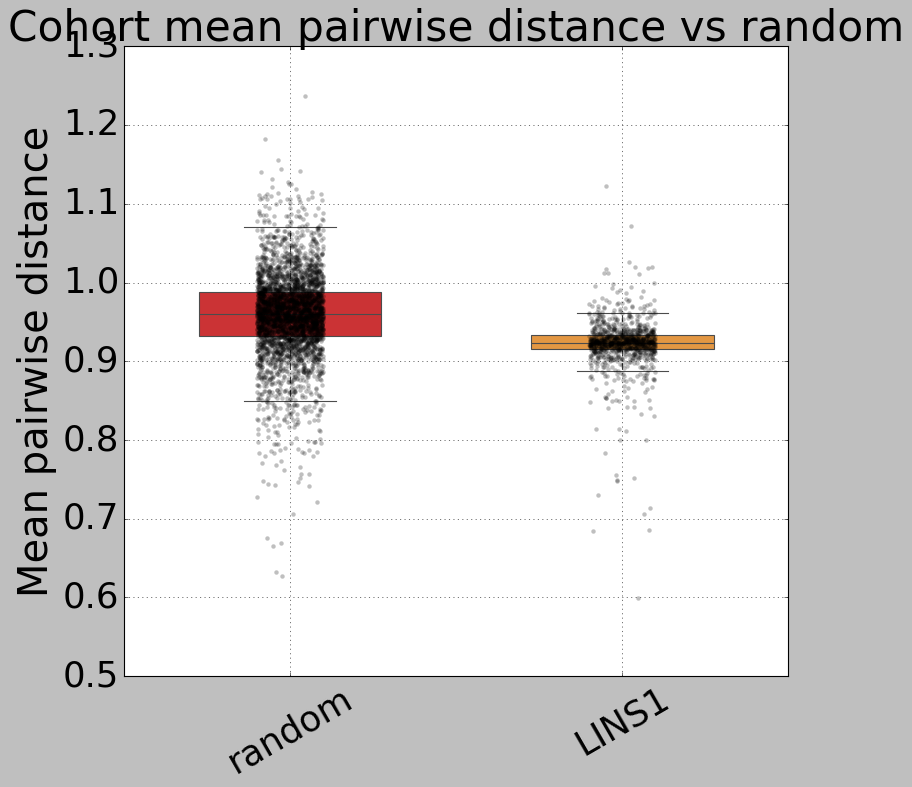

Saved box plot: analysis_output\LINS1_2026_07_01\LINS1_random_vs_target_boxplot.png
LINS1 percentiles within RANDOM empirical distribution:
  n_random = 3540, n_LINS1 = 1000
  random 5th = 0.8649, 50th = 0.9603
  LINS1 mean = 0.9219, median = 0.9236
  LINS1 median percentile in random (lower distance = more similar) = 19.92%
  LINS1 median similarity percentile (higher = more similar) = 80.08%


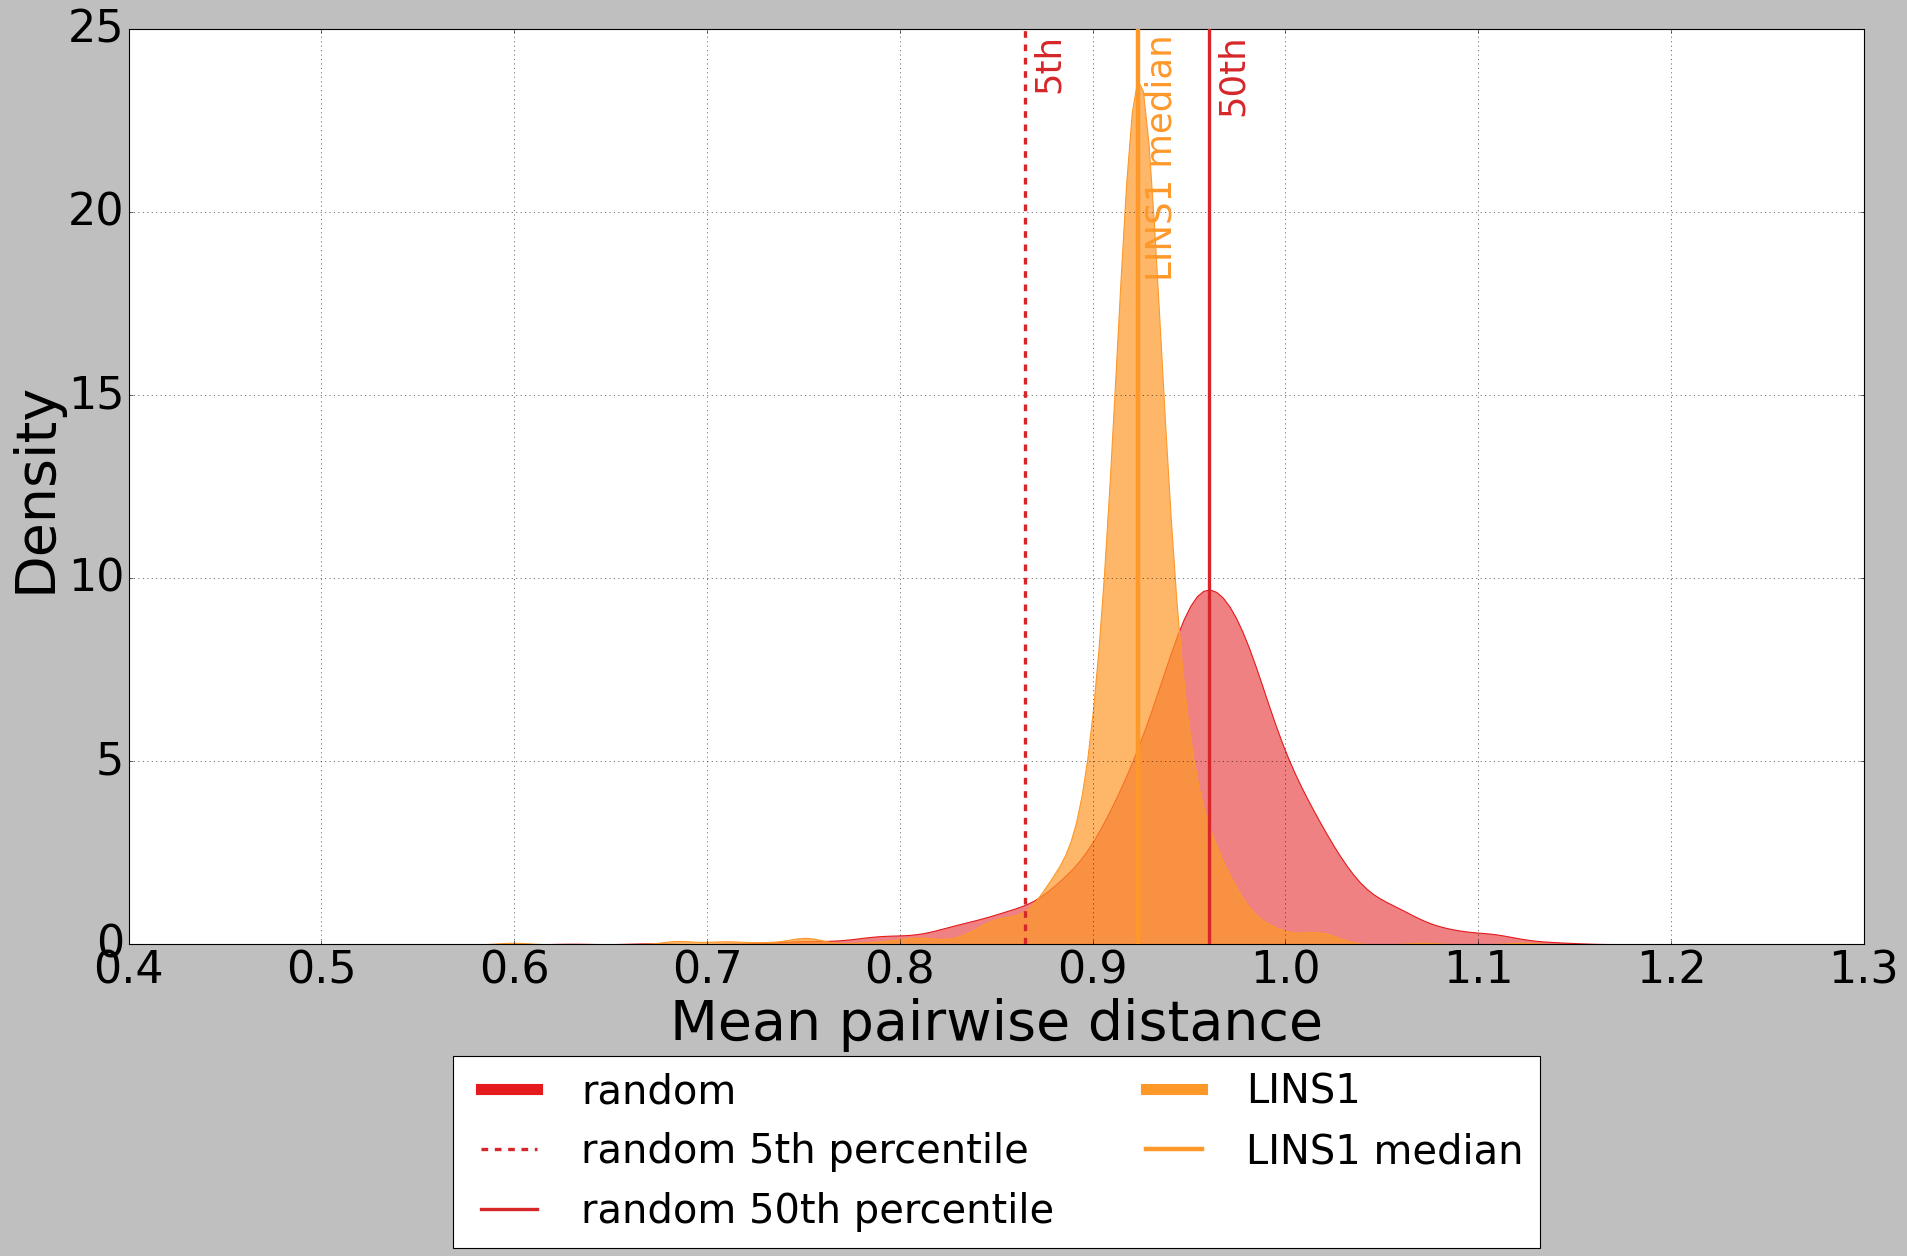

Saved KDE plot: analysis_output\LINS1_2026_07_01\LINS1_random_vs_target_kde.png
Saved KDE percentile report: analysis_output\LINS1_2026_07_01\LINS1_random_vs_target_kde_percentile_report.tsv


,target,n_random,n_target,random_5th,random_median,target_mean,target_median,target_median_percentile_in_random_lower_is_more_similar,target_median_similarity_percentile_higher_is_more_similar,target_sample_percentile_median_lower_is_more_similar,target_sample_similarity_percentile_median_higher_is_more_similar
0,LINS1,3540,1000,0.864859,0.960326,0.921918,0.923571,19.915254,80.084746,19.929379,80.070621


In [15]:
cohort_name = CONFIG.get("target_name", "cohort")

plot_random_vs_target_boxplot(
    distribution_df=combined_random_distribution,
    output_dir=OUTPUT_DIR,
    cohort_name=cohort_name,
    value_col="mean_pw_dist",
    random_label="random",
)

kde_percentile_report_df = plot_random_vs_target_kde(
    distribution_df=combined_random_distribution,
    output_dir=OUTPUT_DIR,
    cohort_name=cohort_name,
    value_col="mean_pw_dist",
    random_label="random",
    xlim=(0.4, 1.3),
)

kde_percentile_report_df

## 6. Cohort-level comparison box plot with PPV report

This section uses a same/different reference distribution to report threshold-based PPV, sensitivity, and specificity.

Then it overlays the selected cohort/group distributions in a box plot.

In [16]:
cross_cfg = CONFIG["cross_cohort_comparison"]

base_key = cross_cfg["base_cohort"]
comparison_cohorts = cross_cfg.get("comparison_cohorts", "all")

n_samples = cross_cfg.get("n_samples", 100)
min_a = cross_cfg.get("min_base_images", 2)
min_b = cross_cfg.get("min_comparison_images", 2)

thr = float(cross_cfg.get("threshold", CONFIG.get("ppv_threshold", 0.8963266102947289)))
p_pretest = float(cross_cfg.get("pretest_probability", 0.5))
top_k = int(cross_cfg.get("top_k", 8))

In [17]:
# ------------------------------------------------------------
# Prepare group_image_ids from target_df
# Each cohort key maps to its image IDs
# ------------------------------------------------------------

group_image_ids = {}

for cohort_name in CONFIG["active_cohorts"]:
    ids = (
        target_df[target_df["cohort"] == cohort_name]["image_id"]
        .astype(str)
        .tolist()
    )

    if len(ids) == 0:
        print(f"Warning: no images found for cohort {cohort_name}")
    else:
        group_image_ids[cohort_name] = ids

print("Prepared cohorts:")
for k, v in group_image_ids.items():
    print(f"  {k}: {len(v)} images")

Prepared cohorts:
  LINS1: 8 images
  CTNND2: 15 images


In [28]:
# ------------------------------------------------------------
# Cross-cohort comparison helper functions
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity


def load_same_different_distributions(path):
    df = pd.read_csv(path)

    required = {"distribution", "mean_pw_dist"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in same/different distribution file: {missing}")

    df = df[["distribution", "mean_pw_dist"]].copy()

    # Normalize labels robustly
    label = (
        df["distribution"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["distribution"] = np.where(
        label.isin(["same", "same syndrome", "same syndromes"]),
        "Same syndromes",
        np.where(
            label.isin(["different", "different syndrome", "different syndromes"]),
            "Different syndromes",
            df["distribution"].astype(str).str.strip()
        )
    )

    same_vals = df.loc[
        df["distribution"] == "Same syndromes",
        "mean_pw_dist"
    ].dropna().to_numpy()

    diff_vals = df.loc[
        df["distribution"] == "Different syndromes",
        "mean_pw_dist"
    ].dropna().to_numpy()

    print("Normalized distribution labels:")
    print(df["distribution"].value_counts())

    if same_vals.size == 0 or diff_vals.size == 0:
        raise ValueError(
            "Need both 'Same syndromes' and 'Different syndromes' in the ROC distribution file."
        )

    return df, same_vals, diff_vals


def get_embeddings_tensor_for_ids(image_ids, rep_df):
    """
    rep_df should contain image IDs and representations.
    Works with either:
        index = image_id
    or:
        column = img_name / image_id
    """

    image_ids = list(map(str, image_ids))
    rep = rep_df.copy()

    possible_rep_cols = ["representations", "representation", "embedding", "embeddings"]
    rep_col = next((c for c in possible_rep_cols if c in rep.columns), None)

    if rep_col is None:
        raise ValueError(
            f"Cannot find representation column. Tried {possible_rep_cols}. "
            f"Available columns: {rep.columns.tolist()}"
        )

    if "img_name" in rep.columns:
        rep["img_name"] = rep["img_name"].astype(str)
        rep = rep.drop_duplicates("img_name").set_index("img_name")
    elif "image_id" in rep.columns:
        rep["image_id"] = rep["image_id"].astype(str)
        rep = rep.drop_duplicates("image_id").set_index("image_id")
    else:
        rep.index = rep.index.astype(str)

    missing = [i for i in image_ids if i not in rep.index]
    if missing:
        raise ValueError(f"Missing {len(missing)} images in representations. First few: {missing[:10]}")

    sub = rep.loc[image_ids]

    E = np.stack([
        np.asarray(v, dtype=np.float32)
        for v in sub[rep_col].values
    ])

    if E.ndim == 2:
        E = E[:, None, :]

    if E.ndim != 3:
        raise ValueError(f"Expected shape N,T,D or N,D. Got {E.shape}")

    return E, np.array(image_ids)


def cosine_distance_matrix_mean_tta(E1, E2):
    """
    Return cross-cohort cosine distance matrix.

    rows    = base cohort images
    columns = comparison cohort images
    """

    if E1.ndim != 3 or E2.ndim != 3:
        raise ValueError("E1 and E2 must be N,T,D tensors.")

    if E1.shape[1:] != E2.shape[1:]:
        raise ValueError(f"TTA / embedding dimension mismatch: {E1.shape} vs {E2.shape}")

    D_sum = None

    for t in range(E1.shape[1]):
        D_t = 1.0 - cosine_similarity(E1[:, t, :], E2[:, t, :])
        D_sum = D_t if D_sum is None else D_sum + D_t

    return D_sum / E1.shape[1]


def sample_mean_cross_distances(D, n_samples=100, min_a=2, min_b=2, seed=0):
    """
    Randomly sample subgroup cross-cohort mean distances.

    D:
        rows    = base cohort images
        columns = comparison cohort images
    """

    rng = np.random.default_rng(seed)

    n_a, n_b = D.shape

    if n_a < min_a:
        raise ValueError(f"Base cohort has only {n_a} images, but min_a={min_a}")

    if n_b < min_b:
        raise ValueError(f"Comparison cohort has only {n_b} images, but min_b={min_b}")

    out = []

    for _ in range(n_samples):
        k_a = int(rng.integers(min_a, n_a + 1))
        k_b = int(rng.integers(min_b, n_b + 1))

        idx_a = rng.choice(n_a, size=k_a, replace=False)
        idx_b = rng.choice(n_b, size=k_b, replace=False)

        out.append(float(D[np.ix_(idx_a, idx_b)].mean()))

    return np.array(out)


def count_unique_patients(image_ids, target_df, id_column):
    tmp = target_df[["image_id", id_column]].copy()
    tmp["image_id"] = tmp["image_id"].astype(str)
    tmp[id_column] = tmp[id_column].astype(str)

    return tmp[tmp["image_id"].isin(set(map(str, image_ids)))][id_column].nunique()


def ppv_different_at_distance(d, same_vals, diff_vals, pretest_probability=0.5):
    """
    PPV for 'different syndrome' at a given distance threshold d.

    Rule:
        positive evidence for different = mean_pw_dist >= d

    Therefore:
        sensitivity = P(distance >= d | Different syndromes)
        specificity = P(distance <  d | Same syndromes)
    """

    p = float(pretest_probability)

    sensitivity = float((diff_vals >= d).mean())
    specificity = float((same_vals < d).mean())

    denom = sensitivity * p + (1.0 - specificity) * (1.0 - p)

    ppv = (sensitivity * p) / denom if denom > 0 else np.nan

    return ppv, sensitivity, specificity


def ppv_range_from_sampled_distances(sampled_means, same_vals, diff_vals, pretest_probability=0.5):
    """
    Calculate PPV for every sampled mean distance, then summarize the PPV range.

    Higher mean pairwise distance = more evidence for different syndrome.
    """

    sampled_means = np.asarray(sampled_means, dtype=float)

    ppv_values = []
    sensitivity_values = []
    specificity_values = []

    for d in sampled_means:
        ppv, sens, spec = ppv_different_at_distance(
            d,
            same_vals=same_vals,
            diff_vals=diff_vals,
            pretest_probability=pretest_probability,
        )

        ppv_values.append(ppv)
        sensitivity_values.append(sens)
        specificity_values.append(spec)

    ppv_values = np.asarray(ppv_values, dtype=float)
    sensitivity_values = np.asarray(sensitivity_values, dtype=float)
    specificity_values = np.asarray(specificity_values, dtype=float)

    return {
        "distance_min": float(np.min(sampled_means)),
        "distance_median": float(np.median(sampled_means)),
        "distance_mean": float(np.mean(sampled_means)),
        "distance_max": float(np.max(sampled_means)),

        "PPV_min": float(np.nanmin(ppv_values)),
        "PPV_25th": float(np.nanquantile(ppv_values, 0.25)),
        "PPV_median": float(np.nanmedian(ppv_values)),
        "PPV_mean": float(np.nanmean(ppv_values)),
        "PPV_75th": float(np.nanquantile(ppv_values, 0.75)),
        "PPV_max": float(np.nanmax(ppv_values)),

        "sensitivity_median": float(np.nanmedian(sensitivity_values)),
        "specificity_median": float(np.nanmedian(specificity_values)),
        "pretest_p": float(pretest_probability),
    }

In [29]:
# ------------------------------------------------------------
# Choose / build representation table for cross-cohort comparison
# ------------------------------------------------------------

def build_rep_df_for_comparison():
    """
    Build one combined representation table from whichever variable exists.

    Preferred:
        cohort_reps: dict of cohort_name -> representation DataFrame

    Also supports:
        all_target_reps
        target_rep_df
        rep_all
    """

    if "all_target_reps" in globals():
        print("Using all_target_reps")
        return all_target_reps.copy()

    if "target_rep_df" in globals():
        print("Using target_rep_df")
        return target_rep_df.copy()

    if "rep_all" in globals():
        print("Using rep_all")
        return rep_all.copy()

    if "cohort_reps" in globals():
        print("Building rep_df_for_comparison from cohort_reps")

        frames = []

        for cohort_name, rep in cohort_reps.items():
            tmp = rep.copy()
            tmp["cohort"] = cohort_name

            # If image ID is stored in the index, move it into img_name
            if "img_name" not in tmp.columns and "image_id" not in tmp.columns:
                tmp = tmp.reset_index()
                first_col = tmp.columns[0]
                tmp = tmp.rename(columns={first_col: "img_name"})

            frames.append(tmp)

        return pd.concat(frames, ignore_index=True)

    raise NameError(
        "Cannot find representation table. Expected one of: "
        "cohort_reps, all_target_reps, target_rep_df, rep_all."
    )


rep_df_for_comparison = build_rep_df_for_comparison()

print(rep_df_for_comparison.shape)
print(rep_df_for_comparison.columns)
rep_df_for_comparison.head()

Building rep_df_for_comparison from cohort_reps
(23, 7)
Index(['img_name', 'model', 'flip', 'gray', 'class_conf', 'representations',
       'cohort'],
      dtype='object')


,img_name,model,flip,gray,class_conf,representations,cohort
0,F1-1,"[m0, m0, m0, m0, m1, m1, m1, m1, m2, m2, m2, m2]","[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]","[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]","[[-2.348189115524292, 0.5999433994293213, -3.6...","[[1.3457622528076172, 0.7316173315048218, -1.7...",LINS1
1,F1-2,"[m0, m0, m0, m0, m1, m1, m1, m1, m2, m2, m2, m2]","[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]","[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]","[[-3.883753538131714, -1.7029911279678345, -4....","[[-1.2071456909179688, 1.2217204570770264, -0....",LINS1
2,F2-1,"[m0, m0, m0, m0, m1, m1, m1, m1, m2, m2, m2, m2]","[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]","[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]","[[1.4780609607696533, -5.51207971572876, -1.20...","[[-1.0570299625396729, -0.6740359663963318, -1...",LINS1
3,F2-2,"[m0, m0, m0, m0, m1, m1, m1, m1, m2, m2, m2, m2]","[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]","[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]","[[1.8475755453109741, -1.6340566873550415, -0....","[[-1.5896872282028198, -0.6886675357818604, -1...",LINS1
4,F2-3,"[m0, m0, m0, m0, m1, m1, m1, m1, m2, m2, m2, m2]","[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1]","[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]","[[-0.6328588128089905, -4.473038196563721, 6.2...","[[-0.27584564685821533, -0.7358664274215698, 0...",LINS1


In [31]:
# ------------------------------------------------------------
# Run cross-cohort comparison
# ------------------------------------------------------------

output_dir = Path(CONFIG.get("output_dir", OUTPUT_DIR))
output_dir.mkdir(parents=True, exist_ok=True)

same_diff_df, same_vals, diff_vals = load_same_different_distributions(
    CONFIG["same_different_distribution_file"]
)

rep_df_for_comparison = build_rep_df_for_comparison()

if base_key not in group_image_ids:
    raise KeyError(
        f"Base cohort '{base_key}' not found in group_image_ids. "
        f"Available keys: {list(group_image_ids.keys())}"
    )

if comparison_cohorts == "all":
    comparison_keys = [k for k in group_image_ids.keys() if k != base_key]
else:
    comparison_keys = list(comparison_cohorts)

missing = [k for k in comparison_keys if k not in group_image_ids]
if missing:
    raise KeyError(
        f"Comparison cohort(s) not found: {missing}. "
        f"Available keys: {list(group_image_ids.keys())}"
    )

base_ids = group_image_ids[base_key]

E_base, base_ids_used = get_embeddings_tensor_for_ids(
    base_ids,
    rep_df_for_comparison,
)

base_n_images = len(base_ids_used)
base_n_patients = count_unique_patients(
    base_ids_used,
    target_df,
    CONFIG["id_column"],
)

comparison_distribution_frames = []
summary_rows = []

for comparison_key in comparison_keys:
    comp_ids = group_image_ids[comparison_key]

    E_comp, comp_ids_used = get_embeddings_tensor_for_ids(
        comp_ids,
        rep_df_for_comparison,
    )

    D = cosine_distance_matrix_mean_tta(E_base, E_comp)

    sampled_means = sample_mean_cross_distances(
        D,
        n_samples=n_samples,
        min_a=min_a,
        min_b=min_b,
        seed=CONFIG.get("random_seed", 0),
    )

    comparison_name = f"{base_key} vs {comparison_key}"

    comparison_distribution_frames.append(pd.DataFrame({
        "mean_pw_dist": sampled_means,
        "distribution": comparison_name,
    }))

    prop_above_c = float((sampled_means > thr).mean())
    evidence_different = bool(prop_above_c > 0.5)

    ppv_stats = ppv_range_from_sampled_distances(
        sampled_means=sampled_means,
        same_vals=same_vals,
        diff_vals=diff_vals,
        pretest_probability=p_pretest,
    )

    comp_n_images = len(comp_ids_used)
    comp_n_patients = count_unique_patients(
        comp_ids_used,
        target_df,
        CONFIG["id_column"],
    )

    summary_rows.append({
        "comparison": comparison_name,
        "base_cohort": base_key,
        "comparison_cohort": comparison_key,

        "mean_pw_distance_all_pairs": float(D.mean()),
        "median_sampled_mean_pw_dist": float(np.median(sampled_means)),
        "mean_sampled_mean_pw_dist": float(np.mean(sampled_means)),

        "threshold_c": thr,
        "prop_sampled_above_c": prop_above_c,
        "evidence_different": evidence_different,

        **ppv_stats,

        "n_samples": int(len(sampled_means)),

        "base_n_images": int(base_n_images),
        "base_n_patients": int(base_n_patients),
        "comparison_n_images": int(comp_n_images),
        "comparison_n_patients": int(comp_n_patients),
    })

cohort_comparison_summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("mean_pw_distance_all_pairs")
    .reset_index(drop=True)
)

cohort_comparison_distributions = pd.concat(
    comparison_distribution_frames,
    ignore_index=True,
)

summary_path = output_dir / f"{base_key}_cohort_comparison_summary.tsv"
dist_path = output_dir / f"{base_key}_cohort_comparison_distributions.tsv"

cohort_comparison_summary_df.to_csv(summary_path, sep="\t", index=False)
cohort_comparison_distributions.to_csv(dist_path, sep="\t", index=False)

print(f"Saved summary: {summary_path}")
print(f"Saved distributions: {dist_path}")

cohort_comparison_summary_df

Normalized distribution labels:
distribution
Different syndromes    156662
Same syndromes           1007
Name: count, dtype: int64
Building rep_df_for_comparison from cohort_reps
Saved summary: analysis_output\LINS1_2026_07_01\LINS1_cohort_comparison_summary.tsv
Saved distributions: analysis_output\LINS1_2026_07_01\LINS1_cohort_comparison_distributions.tsv


,comparison,base_cohort,comparison_cohort,mean_pw_distance_all_pairs,median_sampled_mean_pw_dist,mean_sampled_mean_pw_dist,threshold_c,prop_sampled_above_c,evidence_different,distance_min,...,PPV_75th,PPV_max,sensitivity_median,specificity_median,pretest_p,n_samples,base_n_images,base_n_patients,comparison_n_images,comparison_n_patients
0,LINS1 vs CTNND2,LINS1,CTNND2,0.975441,0.975829,0.977935,0.896327,1.0,True,0.926937,...,0.968834,1.0,0.384461,0.98709,0.5,100,8,8,15,15


C:\Users\la60312\AppData\Local\Temp\ipykernel_64756\3220423416.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


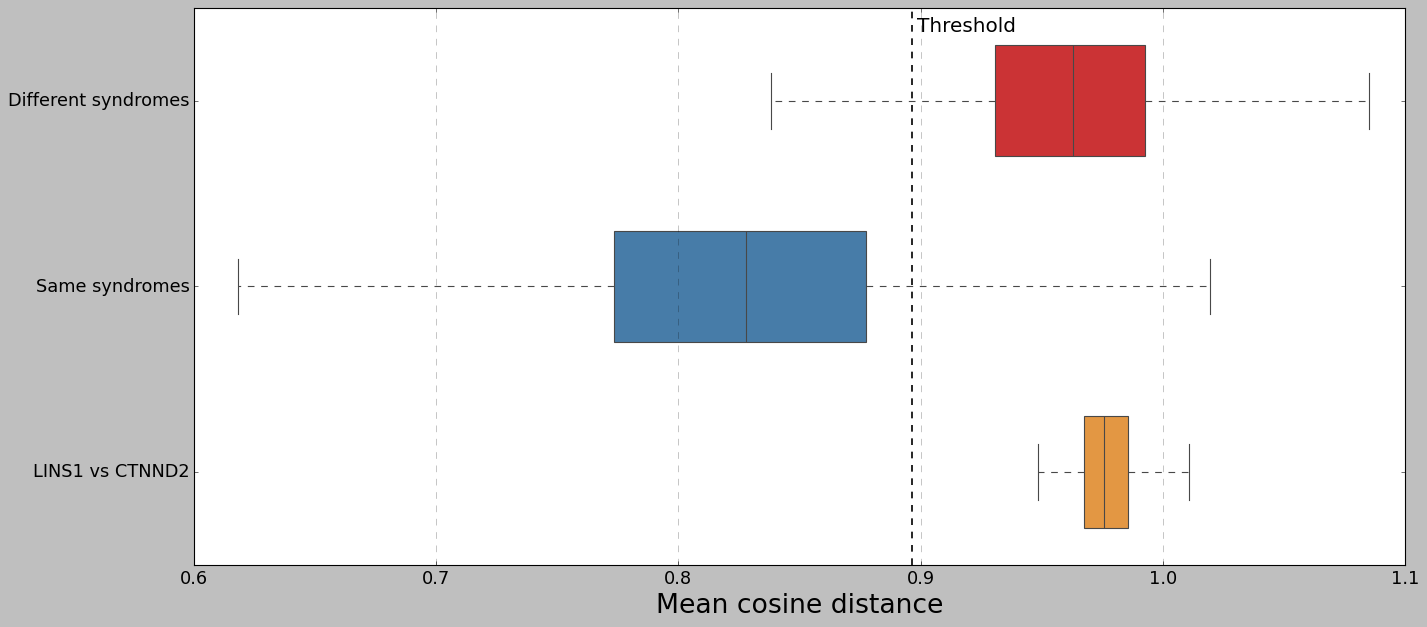

Saved figure: analysis_output\LINS1_2026_07_01\LINS1_cohort_comparison_boxplot.[png/svg/jpeg]


In [32]:
# ------------------------------------------------------------
# Plot same/different controls plus cohort comparison
# ------------------------------------------------------------

def plot_cohort_comparison_boxplot(
    same_diff_df,
    comparison_distributions,
    summary_df,
    output_dir,
    base_key,
    threshold,
    top_k=8,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    distributions_plot = pd.concat(
        [same_diff_df, comparison_distributions],
        ignore_index=True,
    )

    if len(summary_df) > 0:
        show_names = (
            summary_df.head(top_k)["comparison"].tolist()
            + summary_df.tail(top_k)["comparison"].tolist()
        )
        show_names = list(dict.fromkeys(show_names))
    else:
        show_names = []

    plot_names = ["Different syndromes", "Same syndromes"] + show_names

    plot_df = distributions_plot[
        distributions_plot["distribution"].isin(plot_names)
    ].copy()

    comparison_order = (
        summary_df[summary_df["comparison"].isin(show_names)]
        .sort_values("mean_pw_distance_all_pairs")["comparison"]
        .tolist()
    )

    plot_order = ["Different syndromes", "Same syndromes"] + comparison_order

    plt.style.use("classic")
    plt.figure(figsize=(18, max(8, 0.7 * len(plot_order))))

    palette = {
        "Different syndromes": (0.894, 0.102, 0.110),
        "Same syndromes": (0.216, 0.494, 0.722),
    }

    default_comp_color = (
        0.9949711649365629,
        0.5974778931180315,
        0.15949250288350636,
    )

    row_colors = [palette.get(name, default_comp_color) for name in plot_order]

    sns.boxplot(
        data=plot_df,
        y="distribution",
        x="mean_pw_dist",
        order=plot_order,
        palette=row_colors,
        orient="h",
        showfliers=False,
        width=0.6,
    )

    plt.axvline(
        threshold,
        color="black",
        linewidth=1.5,
        linestyle="--",
    )

    plt.text(
        threshold + 0.002,
        -0.4,
        "Threshold",
        fontsize=18,
        ha="left",
        va="center",
    )

    plt.xlabel("Mean cosine distance", fontsize=24)
    plt.ylabel("")
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(True, axis="x", linestyle="--", alpha=0.4)

    plt.tight_layout()

    prefix = output_dir / f"{base_key}_cohort_comparison_boxplot"

    plt.savefig(f"{prefix}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{prefix}.svg", dpi=300, bbox_inches="tight")
    plt.savefig(f"{prefix}.jpeg", dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Saved figure: {prefix}.[png/svg/jpeg]")


plot_cohort_comparison_boxplot(
    same_diff_df=same_diff_df,
    comparison_distributions=cohort_comparison_distributions,
    summary_df=cohort_comparison_summary_df,
    output_dir=output_dir,
    base_key=base_key,
    threshold=thr,
    top_k=top_k,
)

## 7. Final output summary

In [27]:
outputs = sorted([str(p) for p in OUTPUT_DIR.glob("*")])
print("\n".join(outputs))

analysis_output\LINS1_2026_07_01\LINS1_cohort_comparison_boxplot.jpeg
analysis_output\LINS1_2026_07_01\LINS1_cohort_comparison_boxplot.png
analysis_output\LINS1_2026_07_01\LINS1_cohort_comparison_boxplot.svg
analysis_output\LINS1_2026_07_01\LINS1_cohort_comparison_distributions.tsv
analysis_output\LINS1_2026_07_01\LINS1_cohort_comparison_summary.tsv
analysis_output\LINS1_2026_07_01\LINS1_pairwise_distance_matrix.tsv
analysis_output\LINS1_2026_07_01\LINS1_pairwise_rank_heatmap.png
analysis_output\LINS1_2026_07_01\LINS1_pairwise_rank_matrix.tsv
analysis_output\LINS1_2026_07_01\LINS1_random_vs_target_boxplot.jpeg
analysis_output\LINS1_2026_07_01\LINS1_random_vs_target_boxplot.png
analysis_output\LINS1_2026_07_01\LINS1_random_vs_target_boxplot.svg
analysis_output\LINS1_2026_07_01\LINS1_random_vs_target_kde.jpeg
analysis_output\LINS1_2026_07_01\LINS1_random_vs_target_kde.png
analysis_output\LINS1_2026_07_01\LINS1_random_vs_target_kde.svg
analysis_output\LINS1_2026_07_01\LINS1_random_vs_targ